In [ ]:
!nvidia-smi

Mon Jul 21 09:57:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Pip install method (recommended)

!pip install -U ultralytics

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.9/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow --quiet

import roboflow

roboflow.login()

rf = roboflow.Roboflow()

project = rf.workspace("license-plate-m3knv").project("white-license-plate-detector")
dataset = project.version(2).download("yolov8")

/content/datasets
You are already logged into Roboflow. To make a different login,run roboflow.login(force=True).
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to White-License-Plate-Detector-2 in yolov8:: 100%|██████████| 612/612 [00:00<00:00, 6732.75it/s]


In [ ]:
%cd {HOME}
!pip install -U ultralytics
!yolo task=detect mode=train model=yolov8n.pt data={"/content/datasets/White-License-Plate-Detector-2"}/data.yaml epochs=50 imgsz=640 plots=True

/content
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/White-License-Plate-Detector-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

/content


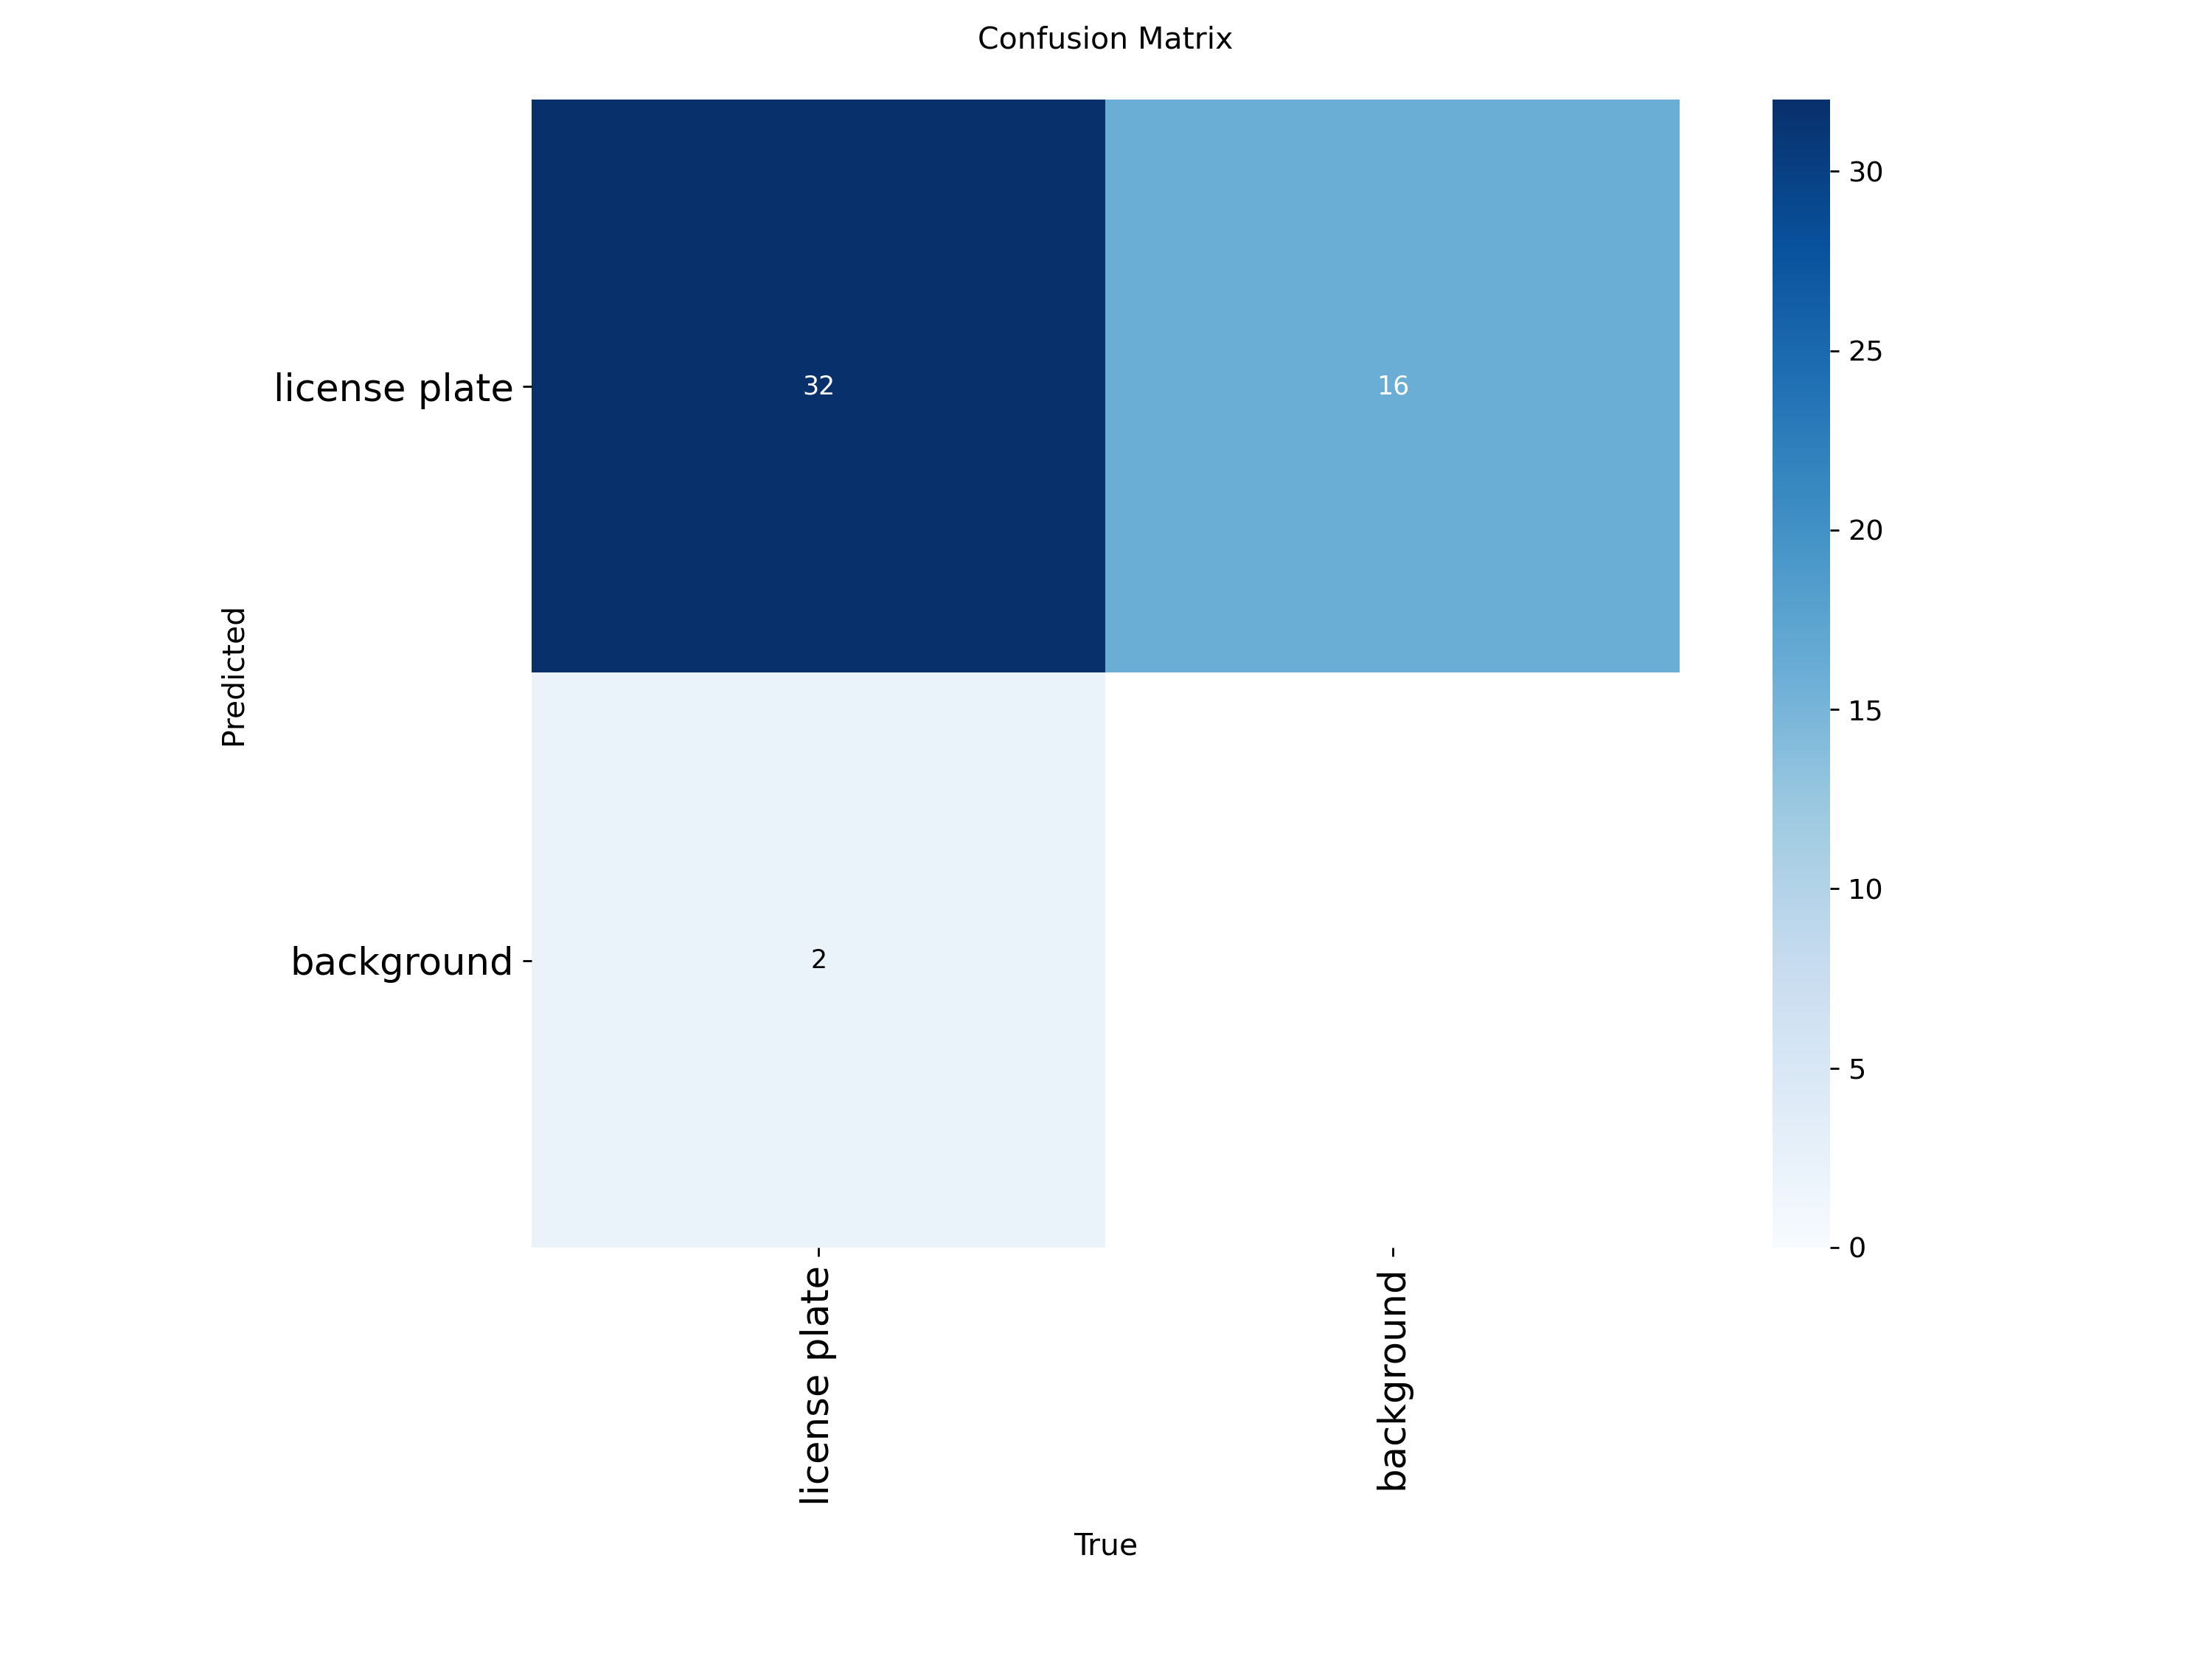

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

/content


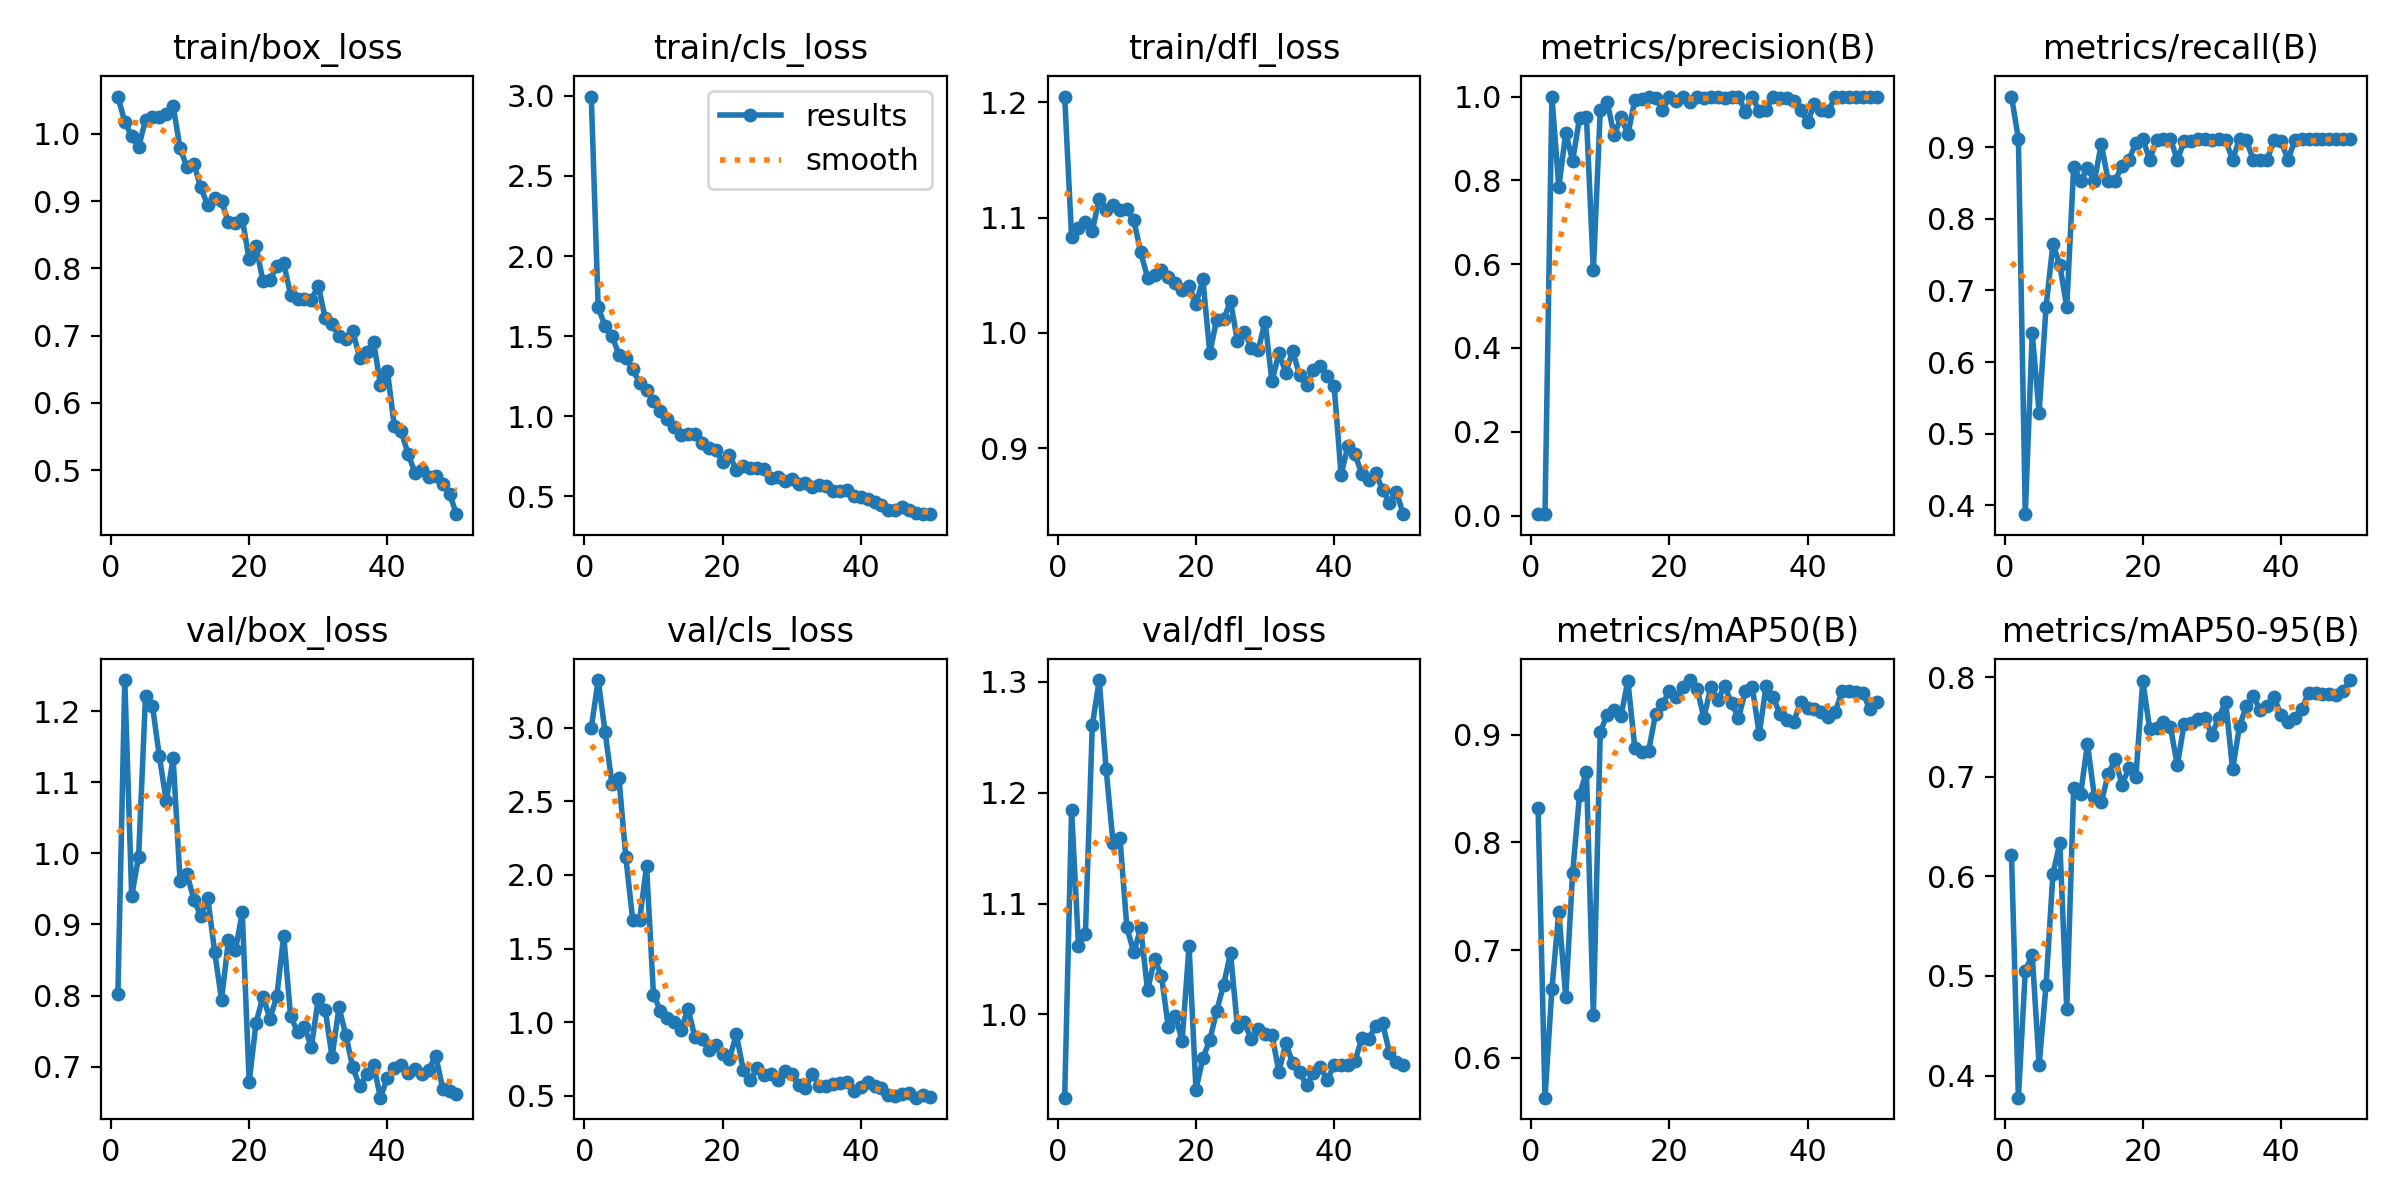

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

/content


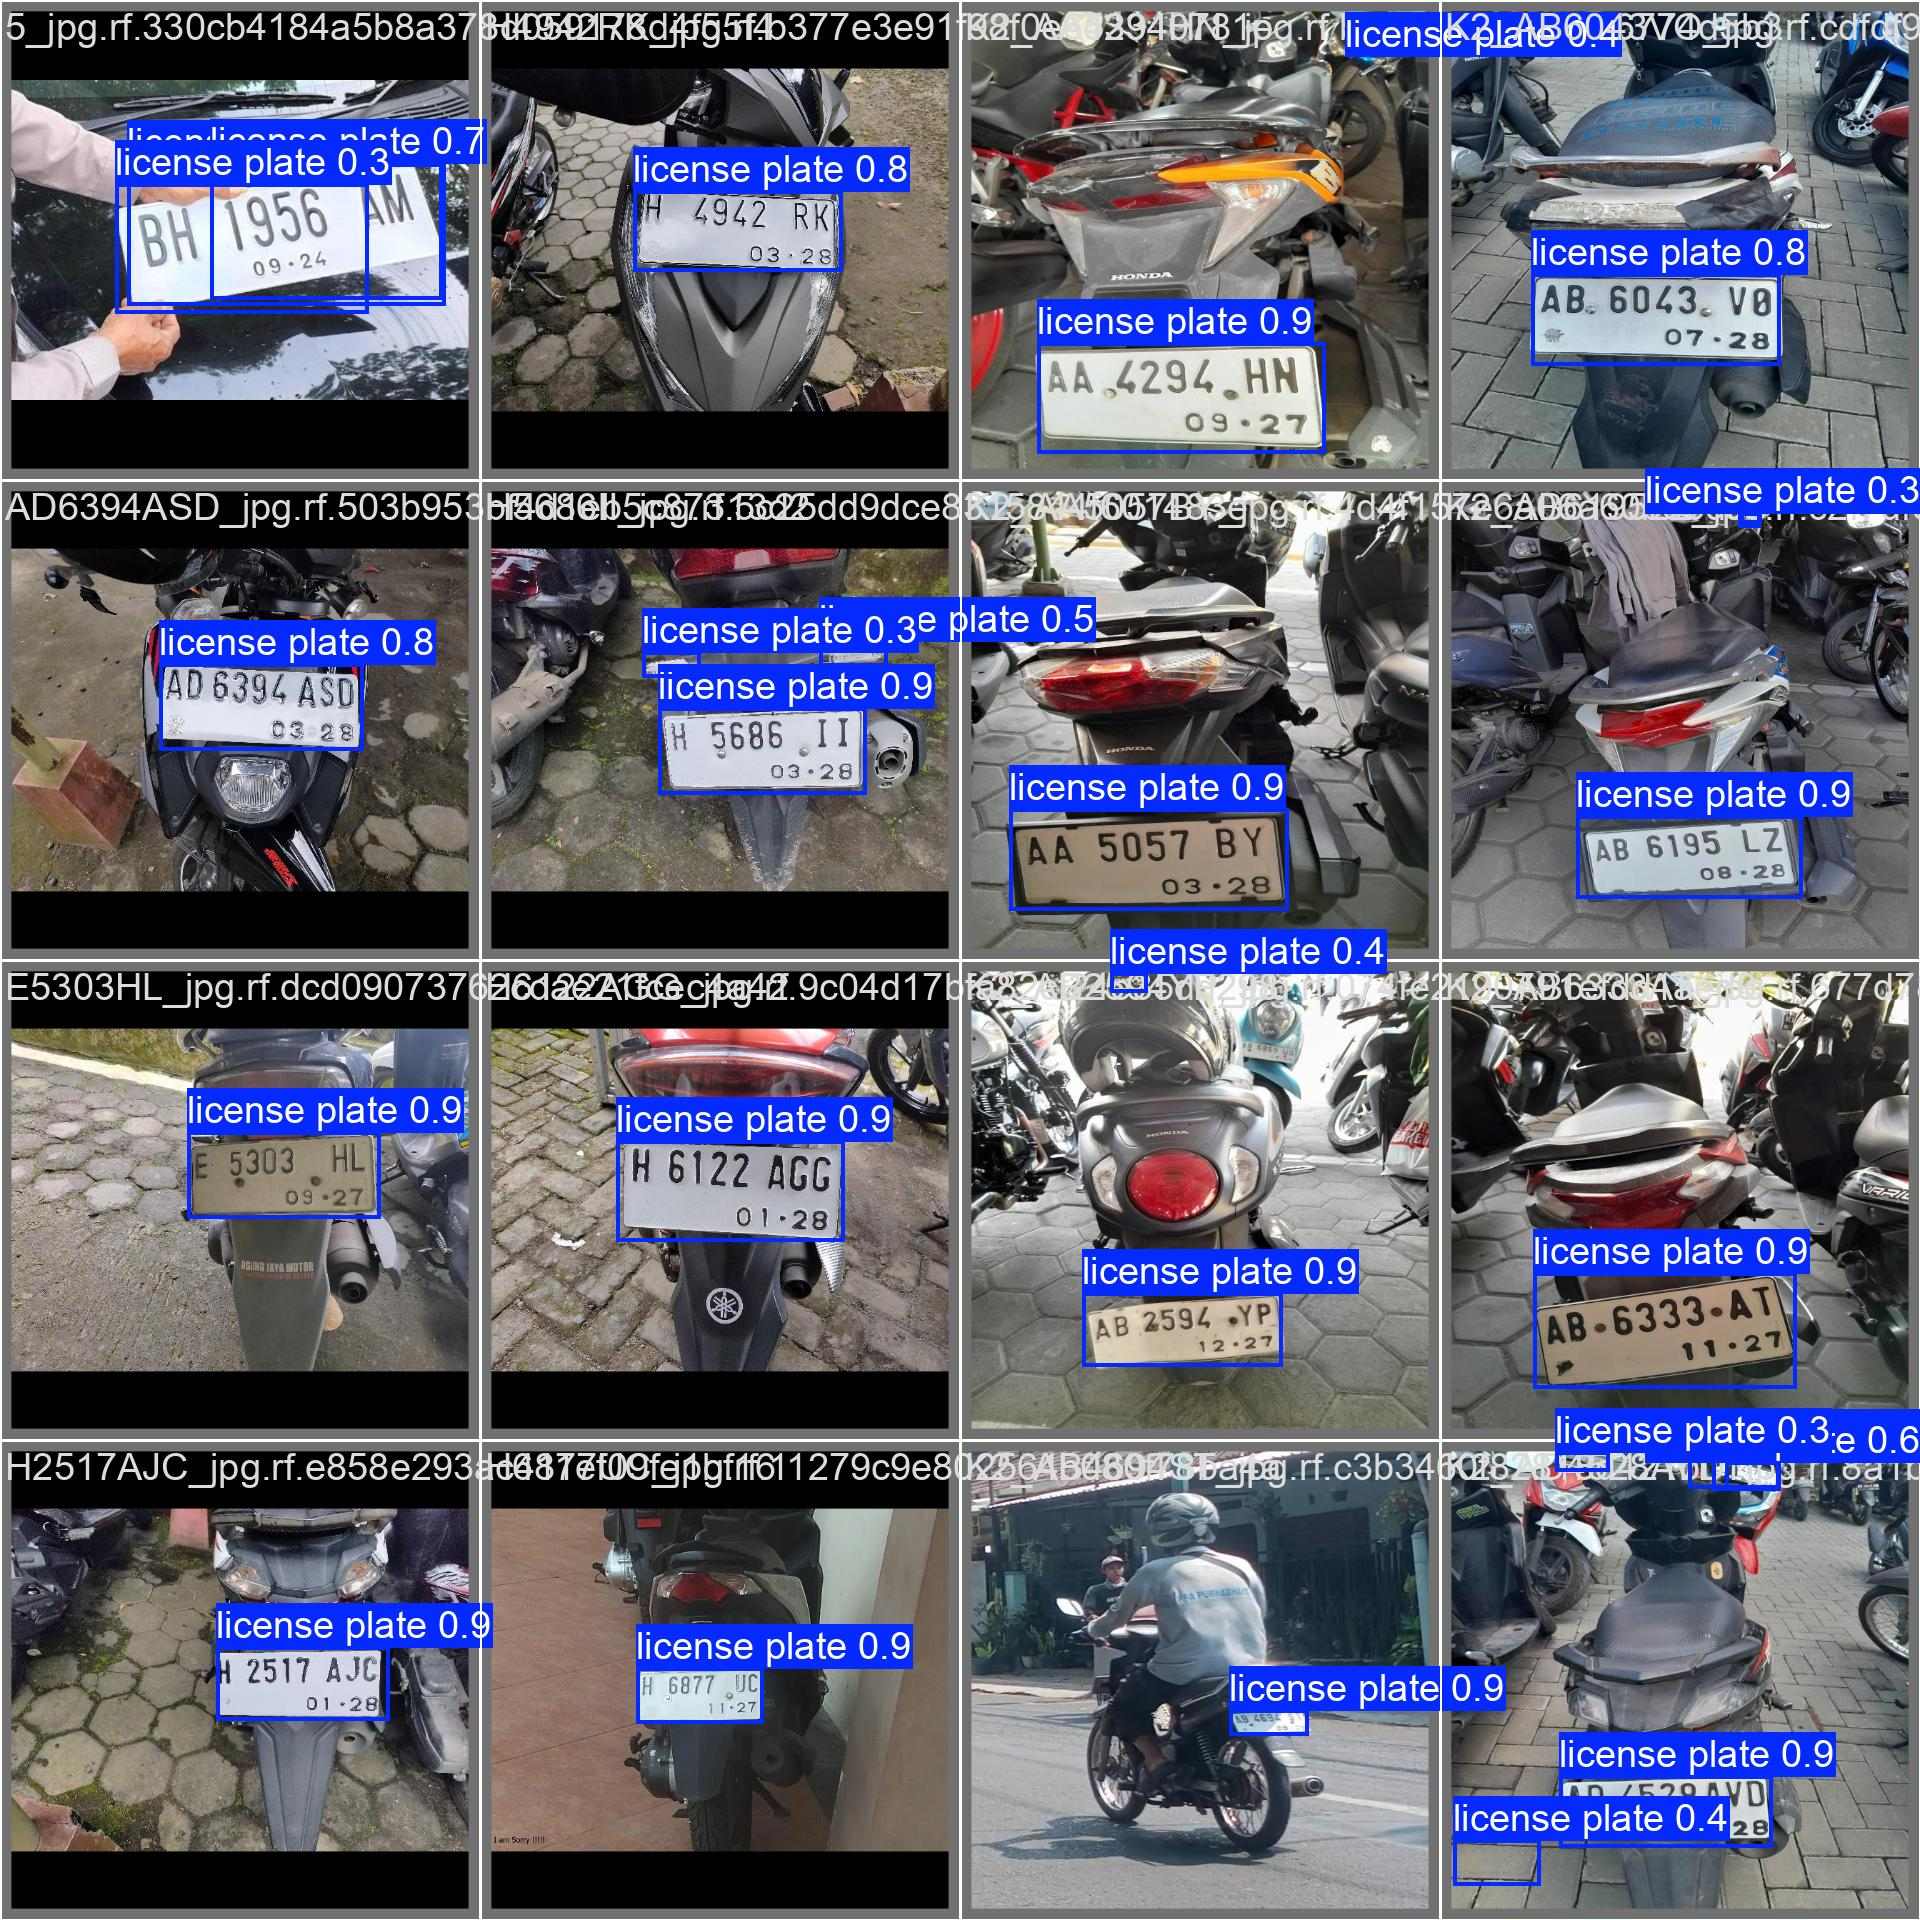

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/val_batch0_pred.jpg', width=600)

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train2/weights/best.pt data={"/content/datasets/White-License-Plate-Detector-2"}/data.yaml

/content
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1088.4±336.6 MB/s, size: 48.9 KB)
val: Scanning /content/datasets/White-License-Plate-Detector-2/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% 30/30 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 2/2 [00:00<00:00,  2.21it/s]
                   all         30         34      0.998      0.912       0.94      0.794
Speed: 0.3ms preprocess, 11.5ms inference, 0.0ms loss, 7.0ms postprocess per image
Results saved to runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train2/weights/best.pt conf=0.3 source={"/content/datasets/White-License-Plate-Detector-2"}/test/images save=True

/content
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/30 /content/datasets/White-License-Plate-Detector-2/test/images/AD3775LW_jpg.rf.ab83aace8a10e6eca850254c92a10ab8.jpg: 640x640 1 license plate, 7.3ms
image 2/30 /content/datasets/White-License-Plate-Detector-2/test/images/H2869QK_jpg.rf.6fb54db5bf51139840b3733be3d4c513.jpg: 640x640 1 license plate, 7.4ms
image 3/30 /content/datasets/White-License-Plate-Detector-2/test/images/H4264RK_jpg.rf.7774a34efd19046c8d6cdfb3db9fc75d.jpg: 640x640 1 license plate, 8.0ms
image 4/30 /content/datasets/White-License-Plate-Detector-2/test/images/H5771OC_jpg.rf.6e8fa05e2cc643bebacc1d8d6293059e.jpg: 640x640 1 license plate, 7.3ms
image 5/30 /content/datasets/White-License-Plate-Detector-2/test/images/H6209HL_jpg.rf.4694895d467b757183eff06d2d34d77d.jpg: 640x640 1 license plate, 7.3ms
image 6/30 /content/datasets/White-License-Pla

In [ ]:
project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train/")